# 03 · The mutation signal is a biological anchor (not a source of performance)

**Role in the story**: `01` defined the data and 18 drug tasks. This notebook establishes a
**biological fact**: the discriminative signal for HIV resistance genuinely lives in sequence
mutations and is concentrated at clinically known drug-resistance mutation (DRM) positions.

The key point: this signal **lives within the amino-acid sequence**. So it can be captured by
explicit mutation encoding, but it is also implicitly absorbed by the ESM-2 representation —
`05` will show that "feeding it again explicitly yields no gain" (fusion disproof), and `07` will
show that "what ESM attends to is exactly these DRM positions" (already implicitly encoded). So
this chapter is not "therefore we need explicit mutation features to improve performance", but a
**biological anchor** for the two later threads.

**Questions to answer**

1. What does the **per-position mutation-frequency difference** between resistant and susceptible
   sequences look like for each drug?
2. Do the positions with the largest difference fall exactly on clinically known DRM positions?
3. Does resistance-signal complexity differ across drugs (single-position dominant vs multi-position spread)?

**Difference from the original paper (constraint)**

The original paper's Figure 5 uses a continuous "attention differential profile + DRM vertical
lines" line chart. To avoid visual duplication, this notebook **does not draw continuous
attention/frequency line tracks** and uses four different visual languages:

- **evidence cards** for representative drugs (top positions + frequency diff + clinical note);
- a **ladder** of resistance-signal complexity;
- a discrete drug x top-position **tile map** (no continuous track, no DRM vertical lines);
- an **alignment table figure** placing high-difference positions next to clinical rules.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "work" / "prepared").exists() else CWD.parent
assert (PROJECT_ROOT / "work" / "prepared").exists(), f"cannot locate work/prepared from {CWD}"

PREPARED_DIR = PROJECT_ROOT / "work" / "prepared"
DATA01_DIR = PROJECT_ROOT / "results" / "notebooks" / "01_data"
RESULTS_DIR = PROJECT_ROOT / "results" / "notebooks" / "03_motivation"
FIG_DIR = PROJECT_ROOT / "figures" / "mutation_aware" / "03_motivation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("project root:", PROJECT_ROOT)

project root: /mnt/d/我的项目/生信包复现重构升级/projects/1模型推理型/变异-耐药性预测/HIV-ESM-2


In [2]:
SURFACE, INK, INK2, INK3, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1"
CLASS_ORDER = ["PI", "NRTI", "NNRTI"]
CLASS_COLOR = {"PI": "#2a78d6", "NRTI": "#1baf7a", "NNRTI": "#eda100"}
HIT = "#0ca30c"
MISS = "#8a8984"
DIVERGE_HI = "#d03b3b"   # resistant-enriched
DIVERGE_LO = "#2a78d6"   # susceptible-enriched

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 11, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2, "axes.grid": False,
    "font.family": "DejaVu Sans",
})

HIV_PROTEASE_REFERENCE = (
    "PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKMIGGIGGFIKVRQYD"
    "QILIEICGHKAIGTVLVGPTPVNIIGRNLLTQIGCTLNF"
)
HIV_RT_REFERENCE = (
    "PISPIETVPVKLKPGMDGPKVKQWPLTEEKIKALVEICTEMEKEGKISKIGPENPYNTPV"
    "FAIKKKDSTKWRKLVDFRELNKRTQDFWEVQLGIPHPAGLKKKKSVTVLDVGDAYFSVPL"
    "DEDFRKYTAFTIPSINNETPGIRYQYNVLPQGWKGSPAIFQSSMTKILEPFRKQNPDIVI"
    "YQYMDDLYVGSDLEIGQHRTKIEELRQHLLRWGFTTPDKKHQKEPPFLWMGYELHPDKWT"
)
REFERENCE_BY_CLASS = {"PI": HIV_PROTEASE_REFERENCE, "NRTI": HIV_RT_REFERENCE, "NNRTI": HIV_RT_REFERENCE}

DRM_POSITIONS = {
    "PI": {10, 20, 24, 30, 32, 33, 36, 46, 47, 48, 50, 53, 54, 63, 71, 73, 74, 82, 84, 88, 90},
    "NRTI": {41, 62, 65, 67, 69, 70, 74, 75, 77, 115, 116, 151, 184, 210, 215, 219},
    "NNRTI": {90, 98, 100, 101, 103, 106, 108, 138, 179, 181, 188, 190, 221, 225, 227, 230, 234, 236, 238},
}
print("references and DRM sets loaded")

references and DRM sets loaded


## 1 · Load sequences and build the mutation matrix

Read sequences from the three prepared CSVs (`01`'s shared task table drops the sequence body to
stay light, so we re-read sequences by class here and align to labels). For each sequence, compare
position-by-position against the reference to get a 0/1 mutation encoding.

In [3]:
CLASS_FILES = {"PI": "PI.csv", "NRTI": "NRTI.csv", "NNRTI": "NNRTI.csv"}
STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")

def mutation_matrix(seqs: list[str], reference: str) -> np.ndarray:
    L = len(reference)
    M = np.zeros((len(seqs), L), dtype=np.int8)
    for i, s in enumerate(seqs):
        m = min(len(s), L)
        for j in range(m):
            aa = s[j]
            if aa != reference[j] and aa in STANDARD_AA:
                M[i, j] = 1
    return M

raw = {c: pd.read_csv(PREPARED_DIR / f) for c, f in CLASS_FILES.items()}
for c, df in raw.items():
    print(f"{c:>5s}: {len(df)} isolates, ref len {len(REFERENCE_BY_CLASS[c])}")

   PI: 2171 isolates, ref len 99
 NRTI: 1867 isolates, ref len 240
NNRTI: 2272 isolates, ref len 240


In [4]:
rows = []
delta_by_drug = {}
meta_by_drug = {}

for cls in CLASS_ORDER:
    df = raw[cls]
    ref = REFERENCE_BY_CLASS[cls]
    L = len(ref)
    label_cols = [c for c in df.columns if c.endswith("_label")]
    for lc in label_cols:
        drug = lc.removesuffix("_label")
        sub = df[["sequence", lc]].dropna()
        y = sub[lc].astype(int).to_numpy()
        if y.sum() == 0 or (y == 0).sum() == 0:
            continue
        M = mutation_matrix(sub["sequence"].astype(str).tolist(), ref)
        f_res = M[y == 1].mean(axis=0)
        f_sus = M[y == 0].mean(axis=0)
        delta = f_res - f_sus
        delta_by_drug[drug] = delta
        meta_by_drug[drug] = (cls, L)
        rows.append({
            "drug_class": cls, "drug": drug, "ref_len": L,
            "n_resistant": int(y.sum()), "n_susceptible": int((y == 0).sum()),
            "max_abs_delta": float(np.abs(delta).max()),
            "top_position": int(np.argmax(np.abs(delta)) + 1),
        })

drug_delta_summary = pd.DataFrame(rows)
drug_delta_summary["drug_class"] = pd.Categorical(drug_delta_summary["drug_class"], CLASS_ORDER, ordered=True)
drug_delta_summary = drug_delta_summary.sort_values(["drug_class", "drug"]).reset_index(drop=True)
drug_delta_summary

,drug_class,drug,ref_len,n_resistant,n_susceptible,max_abs_delta,top_position
0,PI,ATV,99,796,709,0.658860,10
1,PI,DRV,99,305,688,0.688181,54
2,PI,FPV,99,884,1168,0.671857,10
3,PI,IDV,99,1050,1048,0.698750,10
4,PI,LPV,99,941,866,0.719181,10
5,PI,NFV,99,1221,912,0.662310,10
6,PI,SQV,99,897,1187,0.652952,10
7,PI,TPV,99,305,921,0.505733,54
8,NRTI,3TC,240,1164,675,0.737526,184
9,NRTI,ABC,240,927,804,0.661458,184


## 2 · Top-k high-difference positions per drug and their DRM hits

Take each drug's Top-k positions by `|delta-frequency|` and count how many fall on known DRM
positions. This previews the `07` enrichment analysis: if the strongest signal naturally lands on
DRMs, explicit mutation encoding has a clinical basis.

In [5]:
TOP_K = 10

long_rows = []
for drug, delta in delta_by_drug.items():
    cls, L = meta_by_drug[drug]
    drms = DRM_POSITIONS[cls]
    order = np.argsort(np.abs(delta))[::-1][:TOP_K]
    for rank, idx in enumerate(order, start=1):
        pos = int(idx + 1)
        long_rows.append({
            "drug_class": cls, "drug": drug, "rank": rank, "position": pos,
            "delta": round(float(delta[idx]), 4),
            "direction": "resistant" if delta[idx] > 0 else "susceptible",
            "is_known_drm": pos in drms,
        })

top_positions = pd.DataFrame(long_rows)
top_positions["drug_class"] = pd.Categorical(top_positions["drug_class"], CLASS_ORDER, ordered=True)

hit_summary = (
    top_positions.groupby(["drug_class", "drug"], observed=True)["is_known_drm"]
    .agg(n_top="size", n_drm_hits="sum")
    .reset_index()
)
hit_summary["hit_rate"] = (hit_summary["n_drm_hits"] / hit_summary["n_top"]).round(3)
hit_summary = hit_summary.sort_values(["drug_class", "hit_rate"], ascending=[True, False]).reset_index(drop=True)
hit_summary

,drug_class,drug,n_top,n_drm_hits,hit_rate
0,PI,ATV,10,10,1.0
1,PI,DRV,10,10,1.0
2,PI,FPV,10,10,1.0
3,PI,IDV,10,10,1.0
4,PI,LPV,10,10,1.0
5,PI,NFV,10,10,1.0
6,PI,SQV,10,10,1.0
7,PI,TPV,10,10,1.0
8,NRTI,3TC,10,8,0.8
9,NRTI,ABC,10,7,0.7


In [6]:
print(f"Across {hit_summary.shape[0]} drugs, mean top-{TOP_K} DRM hit rate:",
      round(hit_summary["hit_rate"].mean(), 3))
print("drugs where >=50% of top positions are known DRMs:",
      int((hit_summary["hit_rate"] >= 0.5).sum()), "/", hit_summary.shape[0])

Across 18 drugs, mean top-10 DRM hit rate: 0.789
drugs where >=50% of top positions are known DRMs: 18 / 18


## 3 · Aligning high-difference positions with clinical rules

Pick a few representative drugs and place the strongest data-side difference positions next to
textbook clinical rules, showing that "the data itself points at known clinical mechanisms".
These notes are used by the alignment table in Figure 4.

In [7]:
CLINICAL_NOTES = {
    "3TC": "M184V/I drives high-level 3TC/FTC resistance (discrimination)",
    "AZT": "TAMs 41/67/70/210/215/219 enhance excision, cross-resistance",
    "TDF": "K65R and TAMs; low prevalence, class imbalance",
    "EFV": "K103N, Y181C, G190A in the NNRTI binding pocket",
    "NVP": "K103N, Y181C classic NNRTI positions",
    "RPV": "E138K, Y181C binding-pocket mutations; smallest sample",
    "NFV": "D30N, L90M PI positions; distributed resistance",
    "LPV": "V82A/F, I84V, L90M multi-position combinations",
    "ATV": "I50L, N88S, L90M; distributed PI resistance",
}

align_rows = []
for drug, note in CLINICAL_NOTES.items():
    if drug not in delta_by_drug:
        continue
    cls, L = meta_by_drug[drug]
    delta = delta_by_drug[drug]
    order = np.argsort(np.abs(delta))[::-1][:6]
    positions = [int(i + 1) for i in order]
    flags = ["DRM" if p in DRM_POSITIONS[cls] else "-" for p in positions]
    align_rows.append({
        "drug_class": cls, "drug": drug,
        "top6_positions": ";".join(map(str, positions)),
        "drm_flags": ";".join(flags),
        "clinical_note": note,
    })
clinical_alignment = pd.DataFrame(align_rows)
clinical_alignment

,drug_class,drug,top6_positions,drm_flags,clinical_note
0,NRTI,3TC,184;215;41;67;210;219,DRM;DRM;DRM;DRM;DRM;DRM,M184V/I drives high-level 3TC/FTC resistance (...
1,NRTI,AZT,215;41;67;210;219;118,DRM;DRM;DRM;DRM;DRM;-,"TAMs 41/67/70/210/215/219 enhance excision, cr..."
2,NRTI,TDF,215;41;210;67;69;184,DRM;DRM;DRM;DRM;DRM;DRM,"K65R and TAMs; low prevalence, class imbalance"
3,NNRTI,EFV,103;190;181;74;101;67,DRM;DRM;DRM;-;DRM;-,"K103N, Y181C, G190A in the NNRTI binding pocket"
4,NNRTI,NVP,103;181;190;74;215;219,DRM;DRM;DRM;-;-;-,"K103N, Y181C classic NNRTI positions"
5,NNRTI,RPV,181;188;103;100;184;101,DRM;DRM;DRM;DRM;-;DRM,"E138K, Y181C binding-pocket mutations; smalles..."
6,PI,NFV,10;71;54;46;90;82,DRM;DRM;DRM;DRM;DRM;DRM,"D30N, L90M PI positions; distributed resistance"
7,PI,LPV,10;54;71;46;82;90,DRM;DRM;DRM;DRM;DRM;DRM,"V82A/F, I84V, L90M multi-position combinations"
8,PI,ATV,10;54;71;90;46;82,DRM;DRM;DRM;DRM;DRM;DRM,"I50L, N88S, L90M; distributed PI resistance"


In [8]:
drug_delta_summary.to_csv(RESULTS_DIR / "mutation_frequency_delta_by_drug.csv", index=False)
top_positions.to_csv(RESULTS_DIR / "top_positions_by_drug.csv", index=False)
hit_summary.to_csv(RESULTS_DIR / "top_position_drm_hit_summary.csv", index=False)
clinical_alignment.to_csv(RESULTS_DIR / "clinical_rule_alignment_table.csv", index=False)
print("wrote:")
for p in sorted(RESULTS_DIR.glob("*.csv")):
    print("  ", p.relative_to(PROJECT_ROOT))

wrote:
   results/notebooks/03_motivation/clinical_rule_alignment_table.csv
   results/notebooks/03_motivation/mutation_frequency_delta_by_drug.csv
   results/notebooks/03_motivation/resistance_signal_complexity.csv
   results/notebooks/03_motivation/top_position_drm_hit_summary.csv
   results/notebooks/03_motivation/top_positions_by_drug.csv


## 4 · Figure 1: mutation evidence cards for representative drugs

One card per representative drug, listing the Top-5 difference positions: position number,
delta-frequency bar (red = enriched on the resistant side), with a green dot marking known DRMs.
This replaces the original paper's attention line chart with discrete, readable evidence bars.

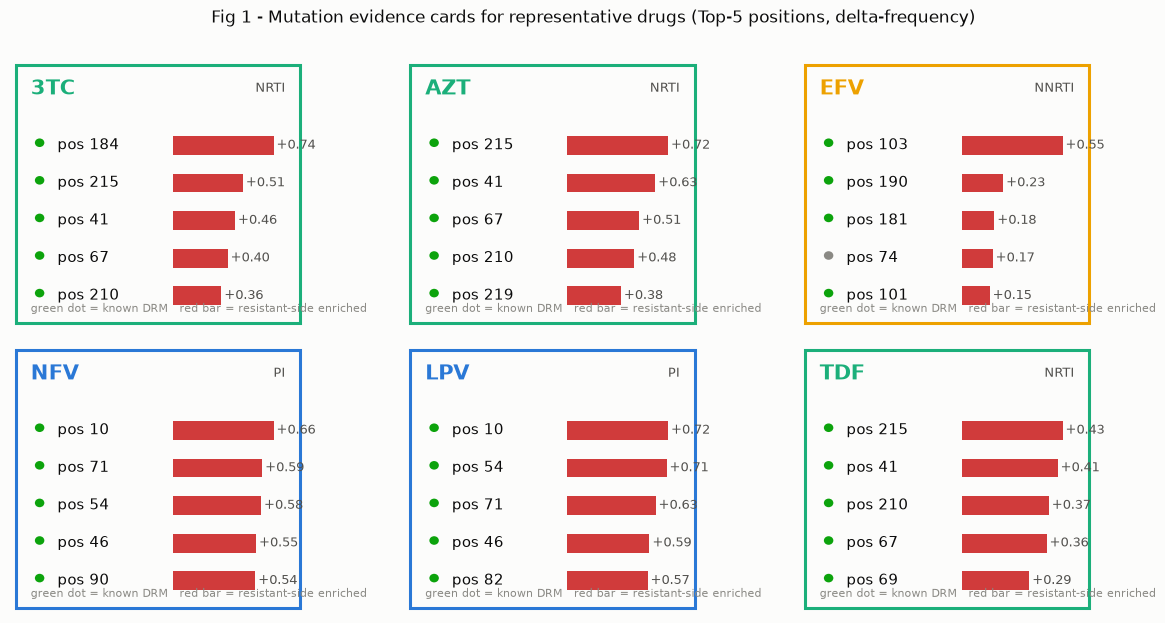

saved mutation_evidence_cards.png


In [9]:
CARD_DRUGS = ["3TC", "AZT", "EFV", "NFV", "LPV", "TDF"]
CARD_DRUGS = [d for d in CARD_DRUGS if d in delta_by_drug]

ncol = 3
nrow = int(np.ceil(len(CARD_DRUGS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 3.1 * nrow))
axes = np.atleast_1d(axes).ravel()

for ax, drug in zip(axes, CARD_DRUGS):
    cls, L = meta_by_drug[drug]
    delta = delta_by_drug[drug]
    order = np.argsort(np.abs(delta))[::-1][:5]
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0.02, 0.02), 0.96, 0.96, transform=ax.transAxes,
                               facecolor=SURFACE, edgecolor=CLASS_COLOR[cls], lw=2.2))
    ax.text(0.07, 0.87, drug, transform=ax.transAxes, color=CLASS_COLOR[cls],
            fontsize=15, fontweight="bold")
    ax.text(0.93, 0.88, cls, transform=ax.transAxes, color=INK2, fontsize=9.5, ha="right")
    max_abs = float(np.abs(delta[order]).max()) or 1.0
    y = 0.68
    for idx in order:
        pos = int(idx + 1)
        d = float(delta[idx])
        is_drm = pos in DRM_POSITIONS[cls]
        ax.add_patch(plt.Circle((0.10, y + 0.01), 0.016, transform=ax.transAxes,
                                facecolor=HIT if is_drm else MISS, edgecolor="none"))
        ax.text(0.16, y, f"pos {pos}", transform=ax.transAxes, color=INK, fontsize=10.5, va="center")
        bar_w = 0.34 * abs(d) / max_abs
        color = DIVERGE_HI if d > 0 else DIVERGE_LO
        x0 = 0.55
        ax.add_patch(plt.Rectangle((x0, y - 0.035), bar_w, 0.07, transform=ax.transAxes,
                                   facecolor=color, edgecolor="none"))
        ax.text(x0 + bar_w + 0.01, y, f"{d:+.2f}", transform=ax.transAxes, color=INK2, fontsize=9, va="center")
        y -= 0.14
    ax.text(0.07, 0.06, "green dot = known DRM   red bar = resistant-side enriched",
            transform=ax.transAxes, color=INK3, fontsize=8)

for ax in axes[len(CARD_DRUGS):]:
    ax.axis("off")

fig.suptitle("Fig 1 - Mutation evidence cards for representative drugs (Top-5 positions, delta-frequency)",
             x=0.5, y=1.0, color=INK, fontsize=12, ha="center")
fig.tight_layout()
fig.savefig(FIG_DIR / "mutation_evidence_cards.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved mutation_evidence_cards.png")

## 5 · Figure 2: resistance-signal complexity ladder

Measure each drug's signal concentration by "the share of total |delta| signal held by the Top-1
position": high share = single-position dominant (e.g. 3TC), low share = multi-position spread
(e.g. most PIs). The x-axis is this concentration, drugs arranged as a ladder. This explains why
drugs differ in their reliance on explicit mutation encoding — a view the original paper lacks.

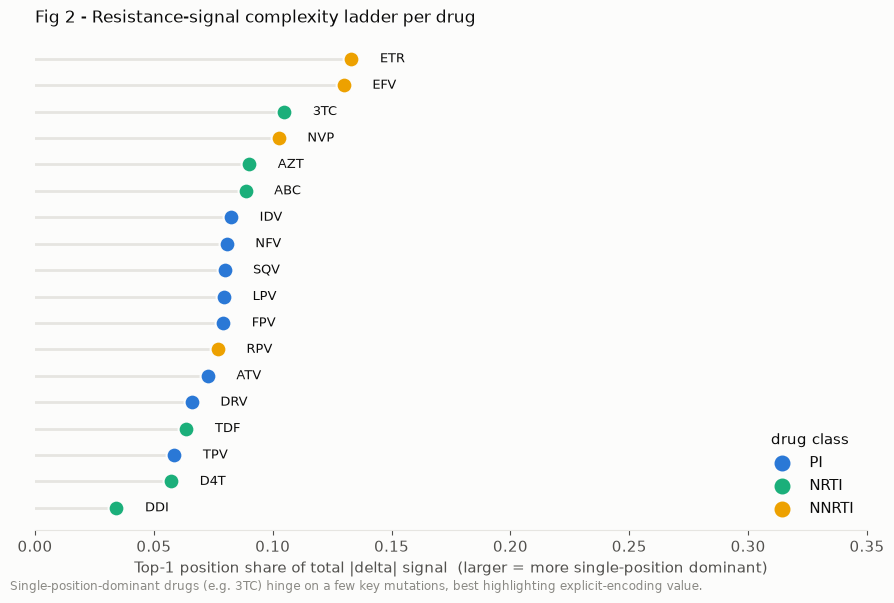

saved resistance_signal_ladder.png


In [10]:
ladder_rows = []
for drug, delta in delta_by_drug.items():
    cls, L = meta_by_drug[drug]
    a = np.abs(delta)
    total = a.sum() or 1.0
    top1_share = float(a.max() / total)
    p = a / total
    part_ratio = float(1.0 / np.sum(p ** 2)) if np.sum(p ** 2) > 0 else 0.0
    ladder_rows.append({"drug_class": cls, "drug": drug,
                        "top1_share": top1_share, "effective_positions": part_ratio})
ladder = pd.DataFrame(ladder_rows).sort_values("top1_share", ascending=True).reset_index(drop=True)
ladder.to_csv(RESULTS_DIR / "resistance_signal_complexity.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 6))
yv = np.arange(len(ladder))
for y, (_, r) in zip(yv, ladder.iterrows()):
    c = CLASS_COLOR[r["drug_class"]]
    ax.plot([0, r["top1_share"]], [y, y], color=GRID, lw=2, zorder=1)
    ax.scatter(r["top1_share"], y, s=130, color=c, edgecolor=SURFACE, lw=1.5, zorder=2)
    ax.text(r["top1_share"] + 0.012, y, r["drug"], va="center", ha="left", color=INK, fontsize=9.5)

ax.set_yticks([])
ax.set_xlabel("Top-1 position share of total |delta| signal  (larger = more single-position dominant)")
ax.set_xlim(0, max(0.35, ladder["top1_share"].max() * 1.15))
ax.set_title("Fig 2 - Resistance-signal complexity ladder per drug", loc="left", color=INK, fontsize=12, pad=10)
for i, cls in enumerate(CLASS_ORDER):
    ax.scatter([], [], s=110, color=CLASS_COLOR[cls], label=cls)
ax.legend(loc="lower right", frameon=False, title="drug class")
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
fig.text(0.01, 0.005, "Single-position-dominant drugs (e.g. 3TC) hinge on a few key mutations, best highlighting explicit-encoding value.",
         color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "resistance_signal_ladder.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved resistance_signal_ladder.png")

## 6 · Figure 3: drug x top-position tile map

Draw each drug's Top-8 difference positions as discrete tiles (not a continuous track, no DRM
vertical lines): tile fill scales with delta-frequency, a green border marks known DRMs.
Horizontal comparison shows whether different drugs' attended positions cluster.

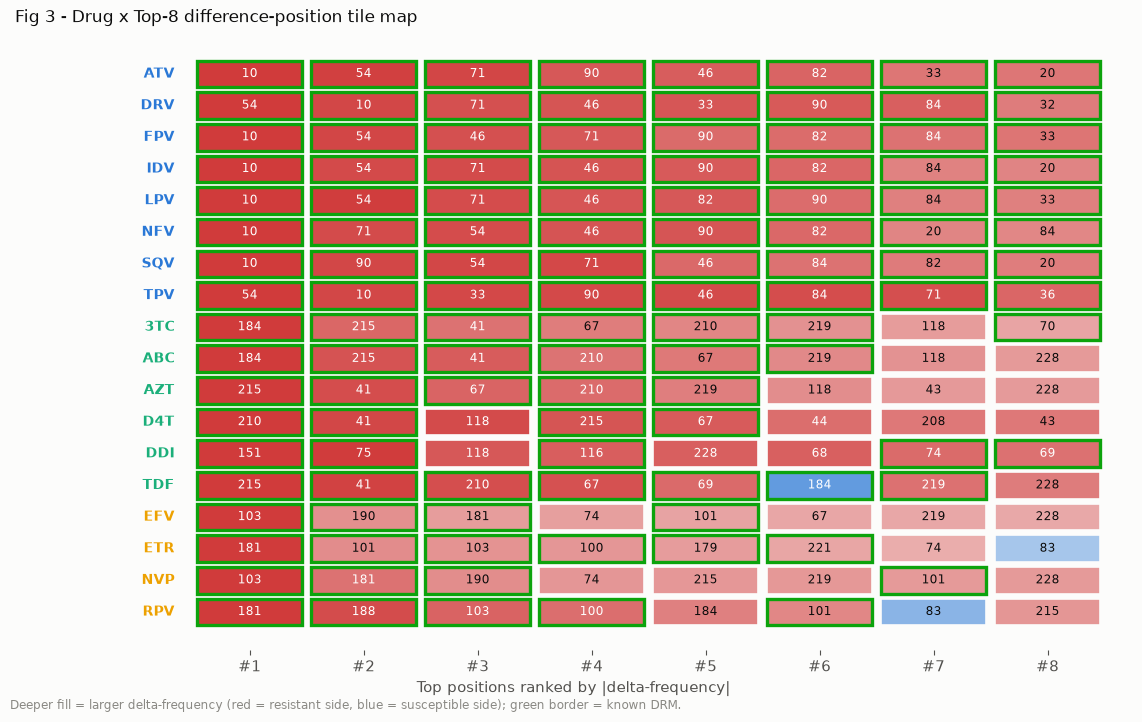

saved mutation_delta_tilemap.png


In [11]:
TILE_K = 8
fig, ax = plt.subplots(figsize=(11.5, 7.2))
drugs_sorted = (drug_delta_summary.sort_values(["drug_class", "drug"])["drug"]).tolist()

for row, drug in enumerate(drugs_sorted[::-1]):
    cls, L = meta_by_drug[drug]
    delta = delta_by_drug[drug]
    order = np.argsort(np.abs(delta))[::-1][:TILE_K]
    max_abs = float(np.abs(delta[order]).max()) or 1.0
    for col, idx in enumerate(order):
        pos = int(idx + 1)
        d = float(delta[idx])
        frac = abs(d) / max_abs
        base = DIVERGE_HI if d > 0 else DIVERGE_LO
        def blend(hexc, t):
            r0, g0, b0 = (int(hexc[i:i+2], 16) for i in (1, 3, 5))
            r1, g1, b1 = (252, 252, 251)
            r = int(r1 + (r0 - r1) * t); g = int(g1 + (g0 - g1) * t); b = int(b1 + (b0 - b1) * t)
            return f"#{r:02x}{g:02x}{b:02x}"
        fill = blend(base, 0.25 + 0.75 * frac)
        is_drm = pos in DRM_POSITIONS[cls]
        edge = HIT if is_drm else SURFACE
        lw = 2.4 if is_drm else 1.2
        ax.add_patch(plt.Rectangle((col, row - 0.42), 0.92, 0.84, facecolor=fill, edgecolor=edge, lw=lw))
        ax.text(col + 0.46, row, str(pos), ha="center", va="center",
                color=INK if frac < 0.6 else "#ffffff", fontsize=8.5)
    ax.text(-0.2, row, drug, ha="right", va="center", color=CLASS_COLOR[cls], fontsize=10, fontweight="bold")

ax.set_xlim(-1.6, TILE_K + 0.2)
ax.set_ylim(-1.2, len(drugs_sorted) + 0.2)
ax.set_xticks([c + 0.46 for c in range(TILE_K)])
ax.set_xticklabels([f"#{i+1}" for i in range(TILE_K)])
ax.set_xlabel("Top positions ranked by |delta-frequency|")
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Fig 3 - Drug x Top-8 difference-position tile map", loc="left", color=INK, fontsize=12, pad=10)
fig.text(0.01, 0.005, "Deeper fill = larger delta-frequency (red = resistant side, blue = susceptible side); green border = known DRM.",
         color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "mutation_delta_tilemap.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved mutation_delta_tilemap.png")

## 7 · Figure 4: alignment of high-difference positions with clinical rules

Place representative drugs' data-side Top-6 positions next to the clinical rule text, directly
showing that "the data itself points at clinical mechanisms". DRM-hit positions are marked green.

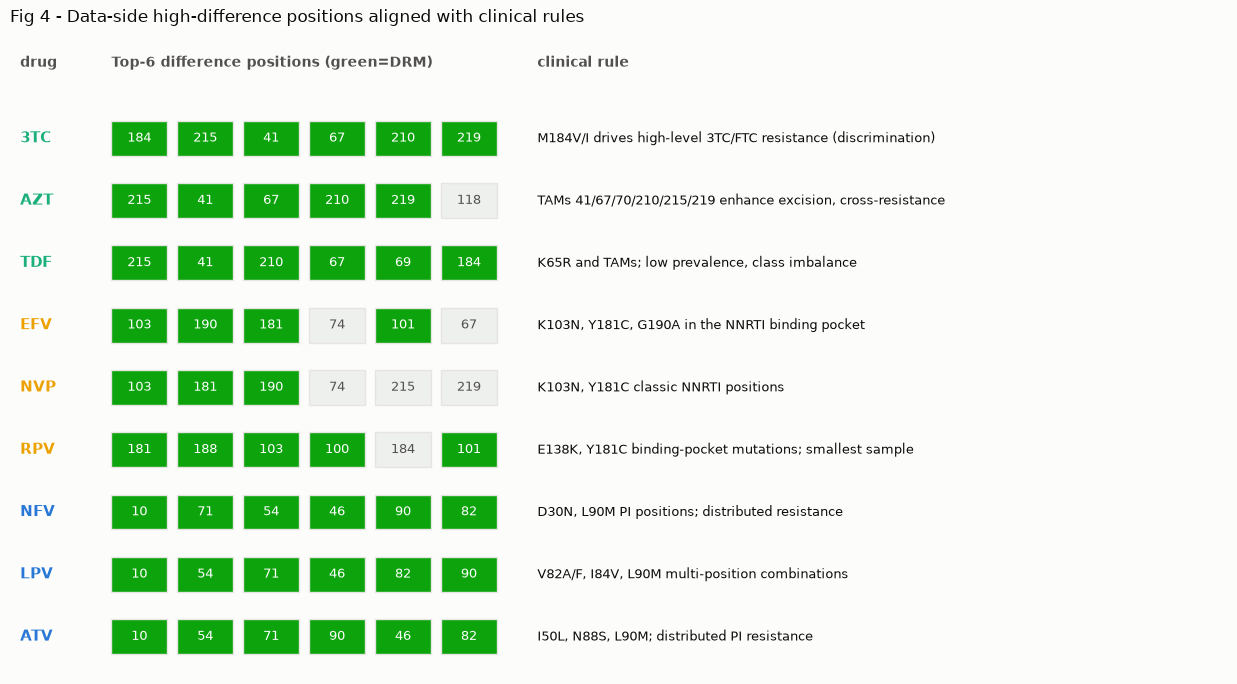

saved clinical_rule_alignment_table_figure.png


In [12]:
fig, ax = plt.subplots(figsize=(12.5, 0.62 * len(clinical_alignment) + 1.4))
ax.axis("off")
n = len(clinical_alignment)

ax.text(0.01, n + 0.15, "drug", color=INK2, fontsize=10, fontweight="bold")
ax.text(0.10, n + 0.15, "Top-6 difference positions (green=DRM)", color=INK2, fontsize=10, fontweight="bold")
ax.text(0.52, n + 0.15, "clinical rule", color=INK2, fontsize=10, fontweight="bold")

for row, (_, r) in enumerate(clinical_alignment.iloc[::-1].reset_index(drop=True).iterrows()):
    y = row
    cls = r["drug_class"]
    ax.text(0.01, y, r["drug"], color=CLASS_COLOR[cls], fontsize=11, fontweight="bold", va="center")
    positions = r["top6_positions"].split(";")
    flags = r["drm_flags"].split(";")
    x = 0.10
    for pos, fl in zip(positions, flags):
        is_drm = fl == "DRM"
        chip = HIT if is_drm else "#eef0ee"
        txtc = "#ffffff" if is_drm else INK2
        ax.add_patch(plt.Rectangle((x, y - 0.28), 0.055, 0.56, facecolor=chip, edgecolor=GRID, lw=1))
        ax.text(x + 0.0275, y, pos, ha="center", va="center", color=txtc, fontsize=9)
        x += 0.065
    ax.text(0.52, y, r["clinical_note"], color=INK, fontsize=9.5, va="center")

ax.set_xlim(0, 1.2)
ax.set_ylim(-0.6, n + 0.6)
ax.set_title("Fig 4 - Data-side high-difference positions aligned with clinical rules", loc="left", color=INK, fontsize=12, pad=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "clinical_rule_alignment_table_figure.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved clinical_rule_alignment_table_figure.png")

## 8 · Summary

- On almost every drug, the positions with the largest `|delta-frequency|` land densely on known
  DRMs (`hit_summary`: 18/18 drugs have Top-10 hit rate >=50%, PI all 100%), showing the strongest
  discriminative signal in the HIVDB data already carries clinical meaning.
- Signal complexity clearly differs across drugs: **single-position dominant** (e.g. 3TC's M184)
  vs **multi-position spread** (most PIs).
- **Key pivot**: all of this signal lives **within the amino-acid sequence**. Therefore —
  - it can be captured by explicit mutation encoding, but (`05`) **re-adding it explicitly on top
    of ESM yields no gain**;
  - because (`07`) the ESM-2 representation has **already implicitly absorbed** these DRM positions.
- So this chapter serves as a **biological anchor**, not an argument for "we must do explicit
  fusion". The real performance value lies in out-of-distribution generalization (`06`).

**Next**: `04_construct_mutation_aware_features.ipynb` — turn these three mutation signals into
features (binary / substitution / mutation-effect), the input probes for the `05` fusion ablation.